In [19]:
import numpy as np

In [20]:
record_file_path = "./data/spike_chain_iter1000_record.npz"

In [21]:
data = np.load(record_file_path)

In [28]:
neuron_indices_all = data['neuron_indices_all']
neuron_indices_all = [(global_id // 256, global_id % 256) for global_id in neuron_indices_all]

In [23]:
spike_times_all = data['spike_times_all']

In [39]:
T = 1000
spiking_mat = np.zeros((T, 29, 256))

In [67]:
for index, neural_idx in enumerate(neuron_indices_all):
    spiking_mat[int(spike_times_all[index]), neural_idx[0], neural_idx[1]] = 1

In [68]:
import matplotlib.pyplot as plt
reduced_mat = spiking_mat.sum(axis=2) / 256

In [69]:
reduced_mat.max()

np.float64(0.03515625)

In [70]:
reduced_mat.flatten().mean(), reduced_mat.flatten().std()

(np.float64(0.0026139547413793103), np.float64(0.004737300568270605))

In [71]:
threshold = reduced_mat.flatten().mean() + reduced_mat.flatten().std()

In [72]:
reduced_mat[reduced_mat < threshold] = 0
reduced_mat[reduced_mat >= threshold] = 1


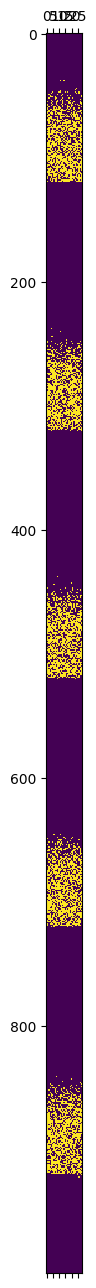

In [73]:
plt.matshow(reduced_mat)

In [76]:
reduced_mat.max()

np.float64(1.0)

In [78]:
from ising_models.ising_model import PairwiseIsingModelInferencer, PairwiseIsingModel, ConfigurationIterator
import numpy as np

In [ ]:
n_sites = 29
ising_model = PairwiseIsingModel(n_sites)
ising_model.J = np.random.rand(n_sites, n_sites)
ising_model.H = np.random.rand(n_sites)

inferencer = PairwiseIsingModelInferencer(ising_model)
inferencer.update_partition_function()

In [ ]:
from ising_trainer import PairwiseIsingModelTrainer
from tqdm import tqdm
total_epoches = 200
trainer = PairwiseIsingModelTrainer(ising_model, inferencer)
loss_record = []
pbar = tqdm(total=total_epoches, desc="Training", unit="epoch")

def on_epoch_end(ctx):
    epoch = ctx.epoch
    epochs = ctx.epochs
    loss = ctx.loss
    kl_loss = ctx.kl_loss
    l2_loss = ctx.l2_loss
    
    pbar.set_description(f"Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}, KL: {kl_loss:.4f}, L2: {l2_loss:.4f}")
    pbar.update(1) 
    loss_record.append(loss)

trained_model = trainer.train(reduced_mat, epochs=total_epoches, learning_rate=0.01, epoch_callback=on_epoch_end)